In [3]:
# like 10, but this time instead of plotting individual runs, 
#    calculate stats on a bunch of validation stacks and plot
#    summary stuff.
# 
# 
import sys, os
src_path = os.path.abspath('../../src')
if src_path not in sys.path:        
    sys.path.insert(0, src_path)
       

print(sys.path)


['/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/src', '/Users/rkennedy/opt/anaconda3/envs/spatial_base/lib/python311.zip', '/Users/rkennedy/opt/anaconda3/envs/spatial_base/lib/python3.11', '/Users/rkennedy/opt/anaconda3/envs/spatial_base/lib/python3.11/lib-dynload', '', '/Users/rkennedy/opt/anaconda3/envs/spatial_base/lib/python3.11/site-packages']


In [4]:
# Example stack config as a pure Python dict

landscape_stack_config = {
    "id_prefix": "DL",
    "id_strategy": "hash",   # or "uuid"
    "explicit_id": None,     # set to a string if you want to force an ID

    # --- Base disturbance landscape setup ---
    

    "disturbance_config": {
        "random": {
            "seed": None,    # or an int for reproducibility
        },
        "raster": {
            "band": 1,
        },
        "types": {
            "type1": {
                "name": "Conifer",
                "proportion_of_patches": 0.6,
                "initial_cover": {
                    "target_mean": 0.90,   # in (0,1)
                    "kappa": 20.0,



                    
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.02,
                        "background_alpha": 0.3,
                        "background_beta": 8.0,
                        "catastrophic_alpha": 8.0,
                        "catastrophic_beta": 0.7,
                    }
                },
            },
            "type2": {
                "name": "Broadleaf",
                "proportion_of_patches": 0.4,
                "initial_cover": {
                    "target_mean": 0.85,
                    "kappa": 18.0,
                },
                "proportional_loss": {
                    "mixture": {
                        "catastrophic_probability": 0.05,
                        "background_alpha": 0.4,
                        "background_beta": 7.0,
                        "catastrophic_alpha": 7.0,
                        "catastrophic_beta": 0.8,
                    }
                },
            },
        },
        "thresholds": {
            "final_cover_percent": 15.0,
        },
        "simulation": {
            "max_retries": 10,
        },
        # Optional plotting defaults (you can ignore or tweak later)
        "plotting": {
            "type_cmap": "tab10",
            "initial_cover_cmap": "Greens",
            "proportional_loss_cmap": "Oranges",
            "loss_abs_cmap": "Reds",
            "final_cover_cmap": "Blues",
            "disturbed_cmap": "Greys_r",
        },
    },

    # --- Sensor configurations (arbitrary number of sensors) ---
    "sensors": [
        {
            "name": "Optical Sensor 1",
            "config": {
                "signal_transform": {
                    "max_signal": 1000.0,
                    "curve_k": 3.0,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.0,
                },
                "types": {
                    # override type-specific behavior if desired
                    "type1": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.0,
                        }
                    },
                    "type2": {
                        "gaussian_patch_noise": {
                            "std_proportion_of_range": 0.0,
                        }
                    },
                },
                "lowpass_filter": {
                    "kernel_size": 0,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 10.0,
                    "amplitude_proportion_of_range": 0.0,
                },
            },
        },

        {
            "name": "Optical Sensor 2",
            "config": {
                "signal_transform": {
                    "max_signal": 1500.0,
                    "curve_k": 2.5,
                },
                "gaussian_patch_noise": {
                    "std_proportion_of_range": 0.015,
                },
                "lowpass_filter": {
                    "kernel_size": 5,
                },
                "spatial_noise": {
                    "spatial_autocorr_distance": 15.0,
                    "amplitude_proportion_of_range": 0.12,
                },
            },
        },
    ],

    # --- Interpreter configuration (single interpreter) ---
    "interpreter": {
        "name": "DefaultInterpreter",
        "config": {
            "detection_curve": {
                "pivot_loss": 15.0,
                "slope": 0.3,
            },
            "definition_curve": {
                "slope": 0.4,
                "threshold_override": None,  # use DisturbanceLandscape threshold by default
            },
            "gaussian_patch_noise": {
                "std_dev_percent": 0.0,
            },
            "beta_patch_uncertainty": {
                "alpha": 0.1,
                "beta": 12.0,
            },
            "lowpass_filter": {
                "kernel_size": 3,
            },
            "spatial_uncertainty": {
                "spatial_autocorr_distance": 20.0,
                "max_scaler": 0.01,
            },
            # --- Per-forest type overrides. 
            "types": {
                    "type1": {
                            "detection_curve":      
                                {"pivot_loss": 15.0, "slope": 0.4},
                            "gaussian_patch_noise": {"std_dev_percent": 0.5},
                            },
                    "type2": {
                "           detection_curve":      
                                {"pivot_loss": 15.0, "slope": 0.2},
                            "gaussian_patch_noise": {"std_dev_percent": 2.0},
                            },

            },
        },
    }
}

In [5]:
train_experiment_config = {
    "n_stacks": 10,
    # "disturbance_seed_base": 10_000,
    "use_separate_seeds_per_stack": True,

    "patch_dir": "../../downloaded_images/",
    # "patch_selection_seed": 123,

    "sensor_name_for_strat": "Optical Sensor 1",
    "n_strata": 5,
    "samples_per_stratum": 50,
    #"kappa_for_logistic":2.0, # no longer needed -- using richards 1.0 is strict logistic, higher is steeper. 
    # "sampling_seed": 42,
}

In [6]:
# set up the interpreters

# new to 06 -- the interpreter stuff
from interpreter_agent import InterpreterAgent, InterpreterGroup

model_building_interp_cfg = {
    "interpreter_id": "interpreterBuildingModel",
    "consistency_std_pct": 0.0,
    "bias_std_pct": 0.0,
    "confidence_std": 0.0,
    # "seed": 101,
}
model_interp1 = InterpreterAgent(**model_building_interp_cfg)

validation_interp1_cfg = {
    "interpreter_id": "validation_interp1",
    "consistency_std_pct": 0.0,
    "bias_std_pct": 0.0,
    "confidence_std": .0,
    # "seed": 101,
}
val_interp1 = InterpreterAgent(**validation_interp1_cfg)



In [7]:
val_experiment_config = {
    "n_stacks": 10,   
    "patch_dir": "../../downloaded_images/",
    "sensor_name_for_strat": "Optical Sensor 1",
    "n_strata": 5,
    "samples_per_stratum": 20,
}



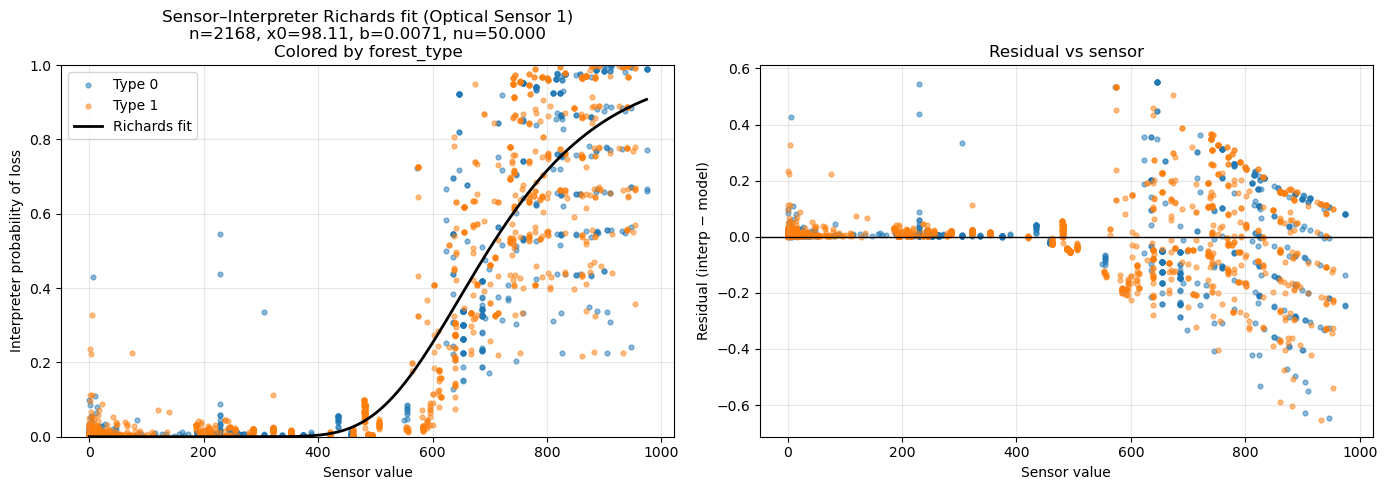

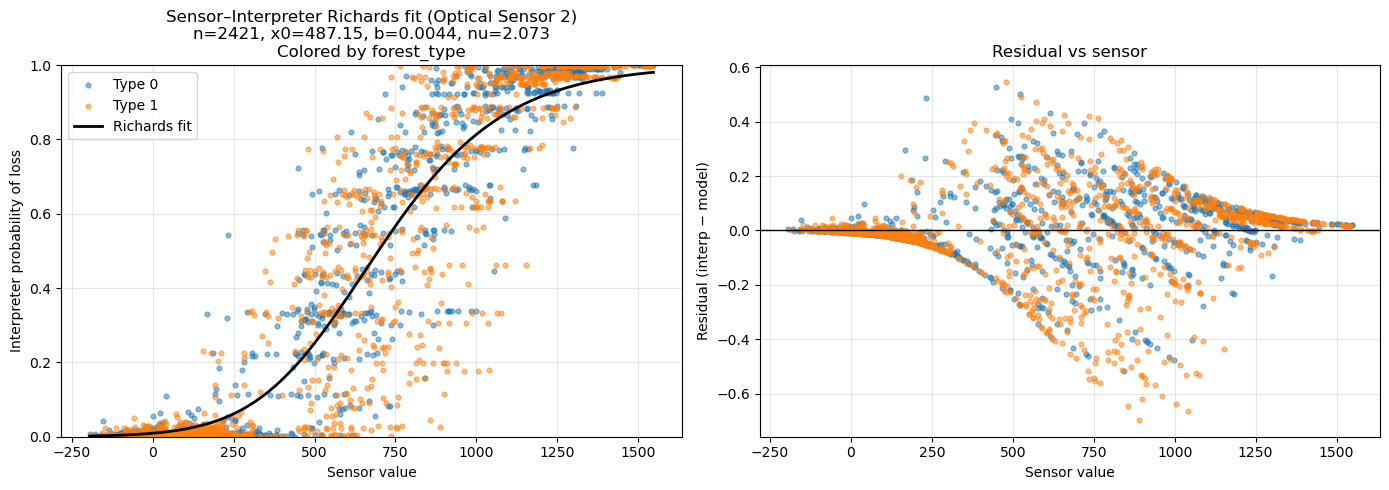

In [8]:
import landscape_stack_collection 
import importlib 
importlib.reload(landscape_stack_collection)
from landscape_stack_collection import LandscapeStackCollection

from disturbance_helper_functions import flatten_config, generate_run_id, _append_to_master_log, export_with_metadata

train_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=train_experiment_config,
)

# Continuous models
trained_models = train_collection.buildModel(
                    sensor_names=None,
                    n_strata=5,
                    samples_per_stratum=50,
                    interpreter_agent=model_interp1,
                            )   #continuous logistic probability





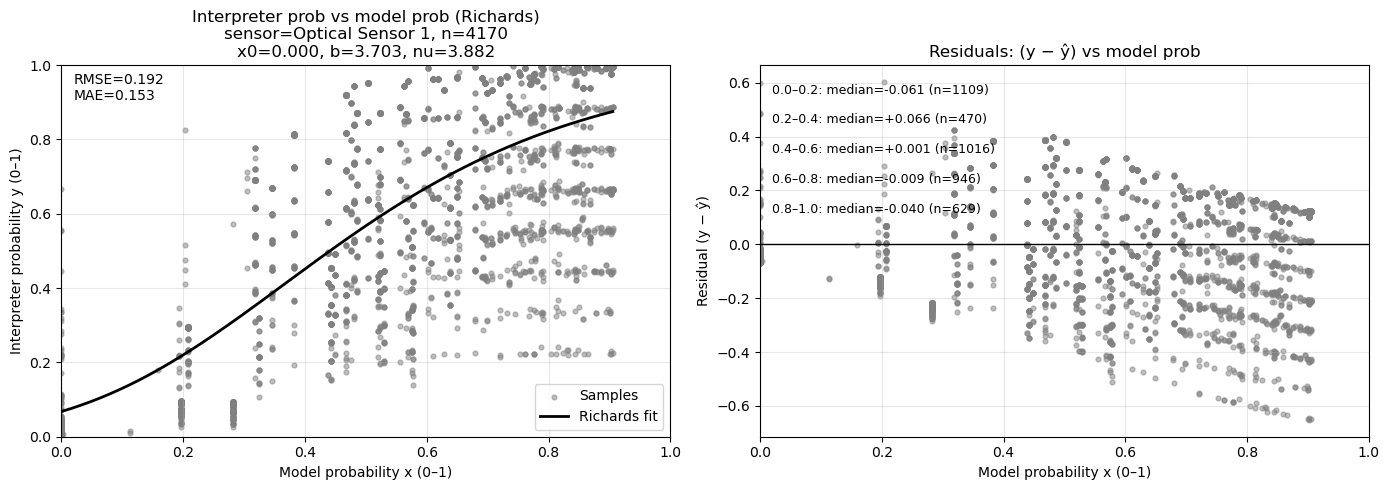

Sample size: 4170
Fitted interpreter-probability model for sensor 'Optical Sensor 1': x0=0.000, b=3.703, nu=3.882


In [9]:
used_tifs = [s.base_landscape.tif_path for s in train_collection.stacks]

val_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=landscape_stack_config,
    experiment_cfg=val_experiment_config,
    exclude_tif_paths=used_tifs,
)


val_collection.loadModel(trained_models)

val_collection.applyModel()

val_collection.buildInterpreterProbModel(
        sensor_name= "Optical Sensor 1", 
        n_strata= 5,
        samples_per_stratum=100,
        sampling_seed=11, 
        interpreter_agent=val_interp1
    )

val_collection.applyInterpreterProbModel(
        sensor_name="Optical Sensor 1", 
        store_attr_name="interpreter_calibrated_prob_by_sensor"
    )

# Binary models
train_collection.buildBinaryClassifier()   # classic binary loss
val_collection.loadBinaryModel(train_collection.binary_models)
val_collection.applyBinaryClassifier()


,stack_index,stack_id,n_pixels,cont_p10,cont_p50,cont_p90,true_prop,abs_err
0,5,DL_ca466745,43632,0.0,0.011895,0.013591,0.011895,0.000000
1,2,DL_c6c3685a,52722,0.0,0.014396,0.014396,0.014396,0.000000
2,6,DL_3b596b2a,42210,0.0,0.017389,0.022009,0.016228,0.001161
3,1,DL_61525db7,47436,0.0,0.021587,0.024686,0.021587,0.000000
4,9,DL_99216a2e,77972,0.0,0.021161,0.022239,0.022239,0.001077


,stack_index,stack_id,W0,W1,bin_mean,bin_se,bin_m2se,bin_p2se,bin_ci_lo,bin_ci_hi,true_prop,abs_err,n_map0,n_map1,samples
0,5,DL_ca466745,0.988105,0.011895,0.009516,0.000478,0.008560,0.010472,0.008579,0.010453,0.011895,0.002379,100,100,stack_id stack_index sensor_nam...
1,2,DL_c6c3685a,0.985604,0.014396,0.012381,0.000502,0.011377,0.013385,0.011397,0.013365,0.014396,0.002015,100,100,stack_id stack_index sensor_nam...
2,6,DL_3b596b2a,0.982611,0.017389,0.013042,0.000757,0.011528,0.014555,0.011559,0.014525,0.016228,0.003186,100,100,stack_id stack_index sensor_nam...
3,1,DL_61525db7,0.978413,0.021587,0.018349,0.000775,0.016800,0.019898,0.016831,0.019867,0.021587,0.003238,100,100,stack_id stack_index sensor_nam...
4,9,DL_99216a2e,0.977761,0.022239,0.019570,0.000726,0.018117,0.021023,0.018147,0.020994,0.022239,0.002669,100,100,stack_id stack_index sensor_nam...


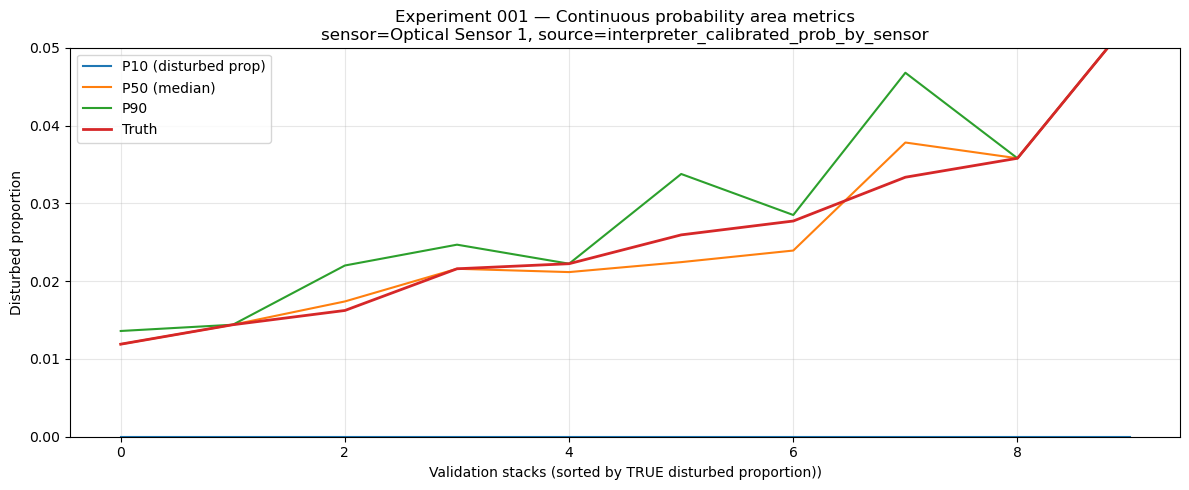

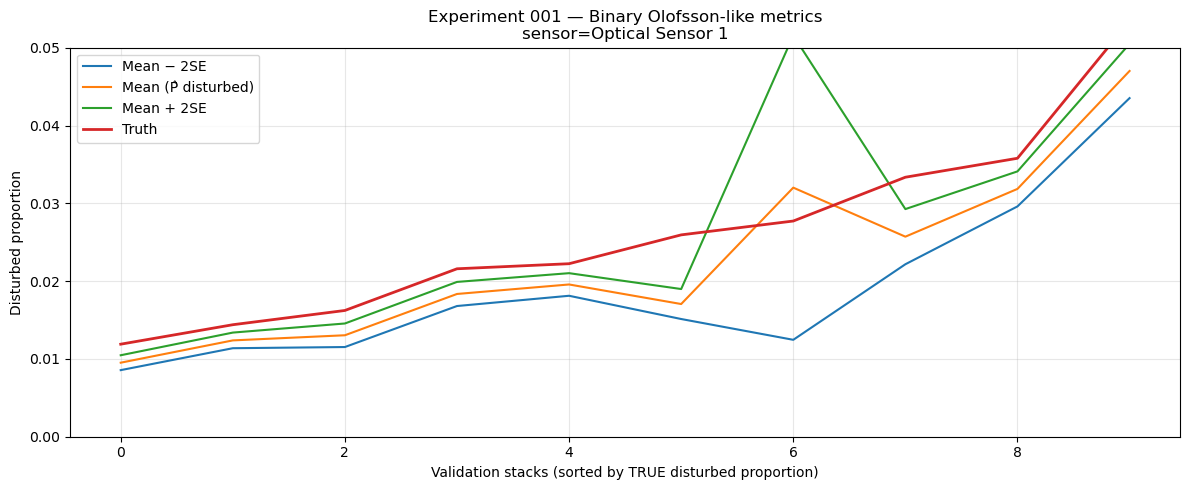

In [10]:
# Evaluate + plot across all validation stacks
out = val_collection.evaluate_validation_collection(
    sensor_name="Optical Sensor 1",
    prob_attr="interpreter_calibrated_prob_by_sensor",
    step=0.001,
    n_samples_map0=100,
    n_samples_map1=100,
    interpreter_agent=val_interp1,    # used only for binary ref_class
    xlim_prop=(0.0, 0.05),            # optional: keep y-axis consistent
    title_prefix="Experiment 001",
)

continuous_df = out["continuous_df"]
binary_df = out["binary_df"]

display(continuous_df.head())
display(binary_df.head())


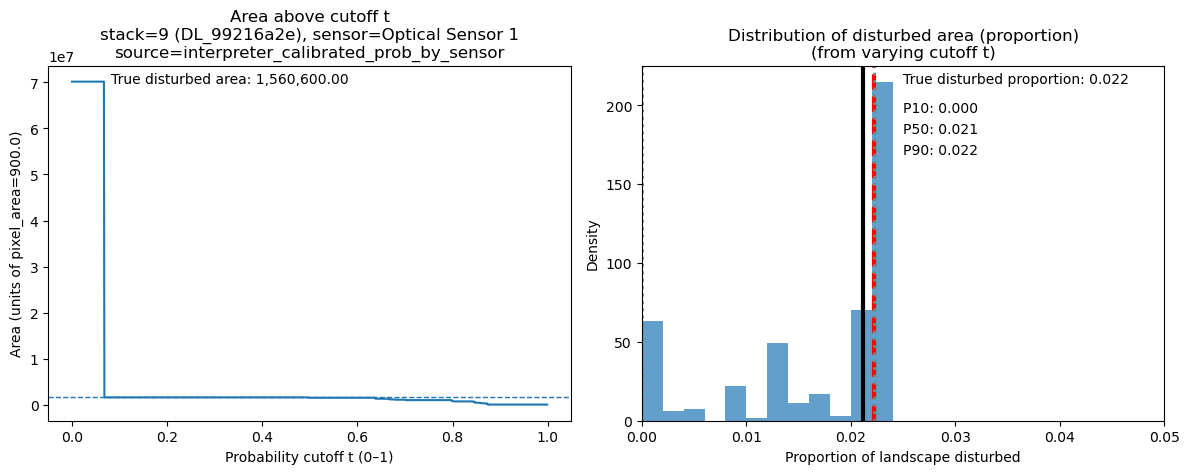

10th, 50th, and 90th percentile DISTURBED PROPORTIONS: 0.000000, 0.021161, 0.022239
True disturbed proportion: 0.022239


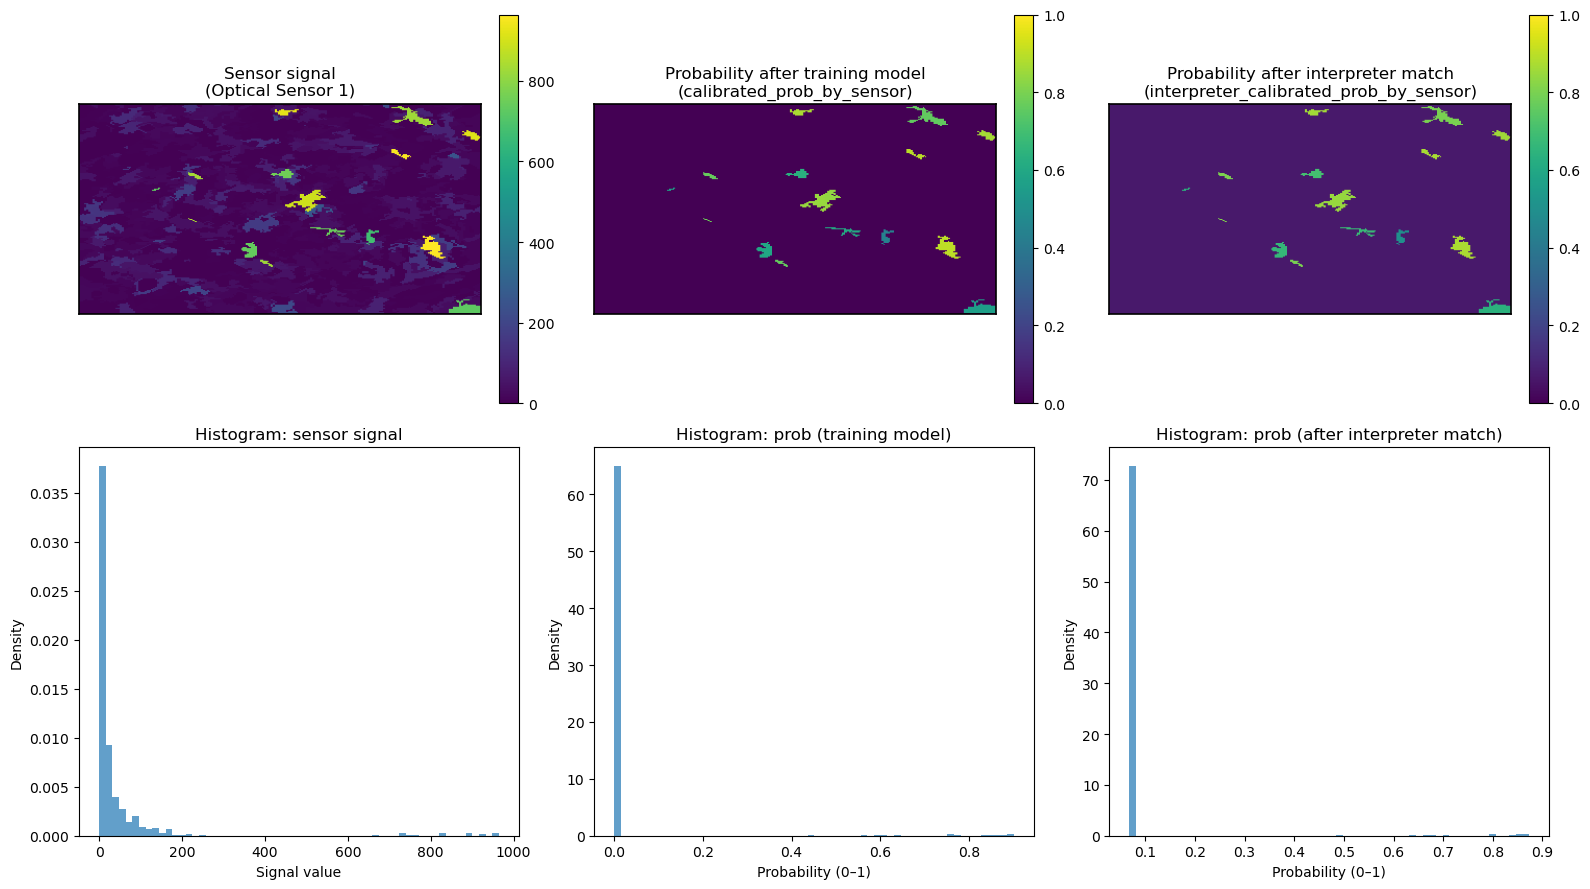


================ AREA PROPORTION SUMMARY (Probability-based) ================
Stack: 9 (DL_99216a2e)   Sensor: Optical Sensor 1   Source: interpreter_calibrated_prob_by_sensor
Total pixels: 77,972   pixel_area: 900.0   total_area: 70,174,800.000

Estimated disturbed proportion P(class 1) from cutoff-sweep distribution:
  P5 :  0.000000
  P50:  0.021161   (median)
  P95:  1.000000

Estimated undisturbed proportion P(class 0) = 1 - P(class 1):
  P5 :  0.000000
  P50:  0.978839   (median)
  P95:  1.000000

Truth (from base_landscape.disturbed):
  True disturbed proportion: 0.022239
  Is truth within [P5, P95] of estimated P(class 1)? True


In [14]:
# print(continuous_df['stack_index'])

interesting_one = 4


stack_index = continuous_df['stack_index'].iloc[interesting_one]


val_collection.plot_area_distribution_for_stack(
    stack_index=stack_index,
    sensor_name="Optical Sensor 1",
    prob_source_attr="interpreter_calibrated_prob_by_sensor",
    pixel_area=900.0,
    step=0.001,
    bins=500,
    x_prop_range=(0.0, 0.05), 
    show_true_area=True,
    show_diagnostics=True,
)




n_ij:
[[100   0]
 [ 12  88]]
n_i: [100 100] n_total: 200

================ CONFUSION MATRIX (Reference vs Classified) ================

                Predicted
              |   0     |    1   
        --------------------------
Reference 0  |    100 |     0
Reference 1  |     12 |    88

Interpretation:
  True Negatives (TN): 100 -- correctly predicted no-loss
  False Positives (FP): 12 -- predicted disturbance where interpreter said none
  False Negatives (FN): 0 -- missed disturbance according to interpreter
  True Positives (TP): 88 -- correctly predicted disturbance

Derived metrics:
  Overall Accuracy:     0.940
  Sensitivity (TPR):    1.000  (recall)
  Specificity (TNR):    0.893
  Precision (PPV):      0.880
  Neg. Predictive Val.: 1.000

Map area proportions W (map class 0,1): 0.978,0.022
Adjusted area proportions P̂ (ref class 0,1): 0.980,0.020
SE(P̂): 0.001 
95% CI (class 0,1):
Map class 0: lower and upper: 0.979, 0.982
Map class 1: lower and upper: 0.018, 0.021
True distu

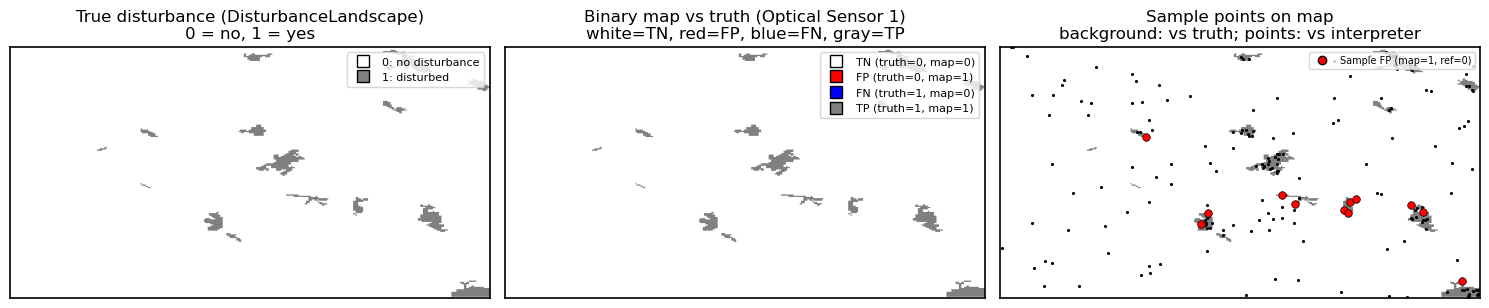

In [15]:
# visualization stuff

row = binary_df[binary_df["stack_index"] == stack_index].iloc[0]
samples_one = row["samples"]   # DataFrame

# 3. Quick confusion matrix check
cm = val_collection.binary_confusion_from_samples(samples_one)
print("n_ij:")
print(cm["n_ij"])
print("n_i:", cm["n_i"], "n_total:", cm["n_total"])
n_ij = cm["n_ij"]

n00, n01 = n_ij[0, 0], n_ij[0, 1]
n10, n11 = n_ij[1, 0], n_ij[1, 1]

TN = n00  # map=0, ref=0
FP = n10  # map=1, ref=0
FN = n01  # map=0, ref=1
TP = n11  # map=1, ref=1

print("\n================ CONFUSION MATRIX (Reference vs Classified) ================\n")
print("                Predicted")
print("              |   0     |    1   ")
print("        --------------------------")
print(f"Reference 0  |  {n00:5d} | {n01:5d}")
print(f"Reference 1  |  {n10:5d} | {n11:5d}")
print("\nInterpretation:")
print(f"  True Negatives (TN): {TN} -- correctly predicted no-loss")
print(f"  False Positives (FP): {FP} -- predicted disturbance where interpreter said none")
print(f"  False Negatives (FN): {FN} -- missed disturbance according to interpreter")
print(f"  True Positives (TP): {TP} -- correctly predicted disturbance\n")

print("Derived metrics:")
total = n00 + n01 + n10 + n11
acc = (TP + TN) / total if total > 0 else float('nan')
sens = TP / (TP + FN) if (TP + FN) > 0 else float('nan')   # recall
spec = TN / (TN + FP) if (TN + FP) > 0 else float('nan')   # specificity
ppv = TP / (TP + FP) if (TP + FP) > 0 else float('nan')    # precision
npv = TN / (TN + FN) if (TN + FN) > 0 else float('nan')

print(f"  Overall Accuracy:     {acc:0.3f}")
print(f"  Sensitivity (TPR):    {sens:0.3f}  (recall)")
print(f"  Specificity (TNR):    {spec:0.3f}")
print(f"  Precision (PPV):      {ppv:0.3f}")
print(f"  Neg. Predictive Val.: {npv:0.3f}")
print("==========================================================================\n")

ol = val_collection.olofsson_area_estimates(
    samples=samples_one, 
    sensor_name="Optical Sensor 1", 
    stack_indices=[stack_index])

print(f'Map area proportions W (map class 0,1): {ol["W"][0]:0.3f},{ol["W"][1]:0.3f}' )
print(f'Adjusted area proportions P̂ (ref class 0,1): {ol["P_hat"][0]:0.3f},{ol["P_hat"][1]:0.3f}')
print(f'SE(P̂): {ol["SE"][0]:0.3f} ')
print('95% CI (class 0,1):')
print(f'Map class 0: lower and upper: {ol["CI"]["lower"][0]:0.3f}, {ol["CI"]["upper"][0]:0.3f}')
print(f'Map class 1: lower and upper: {ol["CI"]["lower"][1]:0.3f}, {ol["CI"]["upper"][1]:0.3f}')

print(f'True disturbed proportion: {ol["true_disturbed_prop"]:0.3f}')
print(f'Is true disturbed within CI for class 1?: {ol["disturbed_in_CI"]}')
val_collection.debug_plot_truth_vs_binary(
    stack_index=stack_index,
    sensor_name="Optical Sensor 1",
    samples=samples_one
)


In [13]:



experiment_config = {
    "landscape_stack_config":  landscape_stack_config, 
    "training_experiment_config": train_experiment_config,
    "training_interp_config": model_building_interp_cfg, 
    "validation_experiment_config": val_experiment_config, 
    "validation_interp_config": validation_interp1_cfg
}


export_with_metadata(experiment_config, notes="adding in individual interpreter noise")


'experiment_logs/run_ID_20260505_122548_28a564.csv'